<a href="https://colab.research.google.com/github/yulia3006/ml-basics/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%968_%D0%9F%D1%80%D0%B8%D0%BC%D0%B5%D0%BD%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D0%BE%D0%B2_%D0%BC%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_%D1%82%D0%B5%D0%BA%D1%81%D1%82%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №8. Применение методов машинного обучения для решения задач классификации текстов. Метод Наивного Байеса. Метод опорных векторов**

## Задание 0. Найдите в глобальной сети или соберите свой датасет для классификации текстов (Пример: новости -> рубрики, комментарии в соц. сетях -> характер, )

* Количество классов в датасете должно превышать 2
* Язык текста в датасете: русский

- ### Пример датасетов: [Russian Texts](https://www.kaggle.com/datasets?search=text+classification+russian)

### Загрузите датасе

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import kagglehub

# загрузка датасета Russian Sentiment Dataset
dataset_path = kagglehub.dataset_download('mar1mba/russian-sentiment-dataset')
df = pd.read_csv(f'{dataset_path}/sentiment_dataset.csv')

df = df.dropna(subset=['text', 'label'])

X = df['text']
y = df['label']

print(f'Размер датасета: {df.shape}')
print(f'Распределение классов:\n{y.value_counts()}')

Размер датасета: (290458, 3)
Распределение классов:
label
2    96992
1    96877
0    96589
Name: count, dtype: int64


### Разделите данные на обучающую и валидационную выборки

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Сохранение пропорций классов
)

print(f'Обучающая выборка: {X_train.shape}')
print(f'Тестовая выборка: {X_test.shape}')

Обучающая выборка: (232366,)
Тестовая выборка: (58092,)


### При выполении дальнейших заданий поэксперементируйте с методами векторизации текста:


1. [Bag of Words](https://habr.com/ru/companies/mlclass/articles/270591/) (BOW): Bag of Words представляет текст как вектор, где каждый элемент обозначает количество вхождений конкретного слова в тексте. Процесс включает в себя создание словаря всех уникальных слов в корпусе текстов и подсчет частоты встречаемости каждого слова в отдельных текстах.

2. [TF-IDF](https://habr.com/ru/companies/otus/articles/755772/) (Term Frequency-Inverse Document Frequency): TF-IDF учитывает не только количество вхождений слова в текст, но и частоту его встречаемости в других текстах. Он вычисляет вес слова, умножая его частоту встречаемости (term frequency) на обратную частоту документа (inverse document frequency). Это позволяет снизить вес наиболее часто встречающихся слов, которые могут быть менее информативными.

3. Word Embeddings (например, [Word2Vec](https://habr.com/ru/articles/446530/) и [GloVe](https://jonathan-hui.medium.com/nlp-word-embedding-glove-5e7f523999f6)): Word Embeddings используют нейронные сети для создания векторных представлений слов, которые учитывают семантическую близость между словами. Нейронные сети обучаются на больших текстовых корпусах и захватывают семантические отношения между словами, что позволяет представить слова в векторном пространстве.

4. One-Hot Encoding: One-Hot Encoding преобразует каждое слово в уникальный вектор, где все элементы равны нулю, за исключением одного, который равен единице. Каждый вектор соответствует отдельному слову и используется для представления его в пространстве признаков.

5. [Count Vectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html): Count Vectorizer подсчитывает количество раз, которое каждое слово встречается в тексте. Он создает вектор, в котором каждый элемент соответствует количеству вхождений конкретного слова в текст.

6. [Hashing Vectorizer](https://kavita-ganesan.com/hashingvectorizer-vs-countvectorizer/): Hashing Vectorizer преобразует каждое слово в уникальный числовой идентификатор с помощью хеширования. Он использует хеш-функцию для преобразования слова в числовое значение, которое затем используется в векторном представлении.

7. [Doc2Vec](https://habr.com/ru/articles/599513/): Doc2Vec является расширением метода Word2Vec и позволяет получить векторное представление не только отдельных слов, но и целых документов или текстов. Алгоритм обучает нейронную сеть, которая учитывает контекст и порядок слов в предложении, чтобы получить векторное представление документа. Это позволяет сравнивать и измерять семантическую близость между целыми текстовыми документами.

#### Оцените влияние разных методов на конечный результат

## Задание 1. Обучите модель классификатора Naive Bayes для решения поставленной задачи, используя пайплайн и подбор оптимальных параметров

In [23]:
pipeline_nb = Pipeline([
    ('vect', TfidfVectorizer()),
    ('clf', MultinomialNB())
])

parameters_nb = {
    'vect__max_df': (0.5, 0.75, 1.0),
    'vect__ngram_range': [(1,1), (1,2)],
    'clf__alpha': (0.01, 0.1, 1.0)
}

grid_search_nb = GridSearchCV(pipeline_nb, parameters_nb, cv=3, n_jobs=-1, scoring='accuracy')
grid_search_nb.fit(X_train, y_train)

print("Лучшие параметры Naive Bayes:", grid_search_nb.best_params_)
best_nb = grid_search_nb.best_estimator_

Лучшие параметры Naive Bayes: {'clf__alpha': 0.1, 'vect__max_df': 0.5, 'vect__ngram_range': (1, 2)}


### Вывод матрицы ошибок:

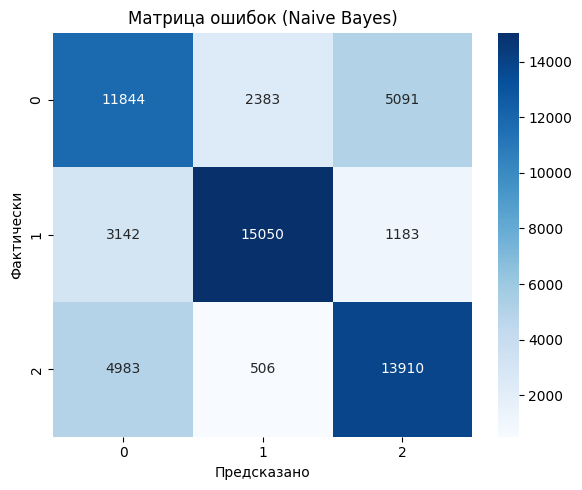

In [24]:
y_pred_nb = best_nb.predict(X_test)
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказано')
plt.ylabel('Фактически')
plt.title('Матрица ошибок (Naive Bayes)')
plt.tight_layout()
plt.show()

### Оценка точности:

In [25]:
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Accuracy (Naive Bayes): {acc_nb:.4f}\n")
print(classification_report(y_test, y_pred_nb))

Accuracy (Naive Bayes): 0.7024

              precision    recall  f1-score   support

           0       0.59      0.61      0.60     19318
           1       0.84      0.78      0.81     19375
           2       0.69      0.72      0.70     19399

    accuracy                           0.70     58092
   macro avg       0.71      0.70      0.70     58092
weighted avg       0.71      0.70      0.70     58092



## Задание 2. Обучите модель SVM (метод опорных векторов) для решения поставленной задачи, используя пайплайны и подбор оптимальных параметров

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import numpy as np

pipeline_svm = Pipeline([
    ('vect', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), dtype=np.float32)),
    ('clf', SVC(kernel='linear', max_iter=2000, tol=1e-3, random_state=42))
])

parameters_svm = {
    'vect__max_df': [0.75, 1.0],
    'vect__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.1, 1.0, 5.0]
}

grid_search_svm = GridSearchCV(
    pipeline_svm,
    parameters_svm,
    cv=3,
    n_jobs=1,
    scoring='accuracy',
    verbose=1
)
grid_search_svm.fit(X_train, y_train)

print("Лучшие параметры SVM:", grid_search_svm.best_params_)
best_svm = grid_search_svm.best_estimator_

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider

Лучшие параметры SVM: {'clf__C': 0.1, 'vect__max_df': 0.75, 'vect__ngram_range': (1, 1)}


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


### Вывод матрицы ошибок:

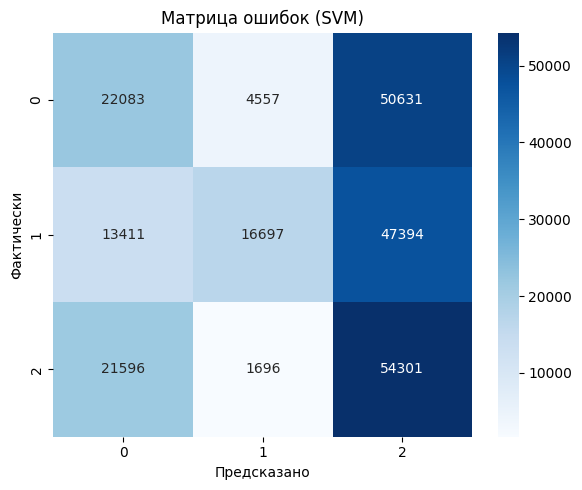

In [27]:
y_pred_svm = best_svm.predict(X_train)
cm_svm = confusion_matrix(y_train, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказано')
plt.ylabel('Фактически')
plt.title('Матрица ошибок (SVM)')
plt.tight_layout()
plt.show()

### Оценка точности:

In [28]:
acc_svm = accuracy_score(y_train, y_pred_svm)
print(f"Accuracy (SVM): {acc_svm:.4f}\n")
print(classification_report(y_train, y_pred_svm))

Accuracy (SVM): 0.4006

              precision    recall  f1-score   support

           0       0.39      0.29      0.33     77271
           1       0.73      0.22      0.33     77502
           2       0.36      0.70      0.47     77593

    accuracy                           0.40    232366
   macro avg       0.49      0.40      0.38    232366
weighted avg       0.49      0.40      0.38    232366



## Задание 3. Обучите модель классификатора Decision Tree Classifier для решения поставленной задачи

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

# Pipeline для Decision Tree
pipeline_dt = Pipeline([
    ('vect', TfidfVectorizer(max_features=2000, ngram_range=(1,1), sublinear_tf=True)),
    ('clf', DecisionTreeClassifier(max_depth=15, min_samples_split=10, min_samples_leaf=5, random_state=42))
])

# обучение
pipeline_dt.fit(X_train, y_train)

# Ппредсказание
y_pred_dt = pipeline_dt.predict(X_test)

# оценка
print("Decision Tree accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree accuracy: 0.51838463127453
              precision    recall  f1-score   support

           0       0.47      0.35      0.40     19318
           1       0.54      0.67      0.59     19375
           2       0.53      0.54      0.54     19399

    accuracy                           0.52     58092
   macro avg       0.51      0.52      0.51     58092
weighted avg       0.51      0.52      0.51     58092



### Вывод матрицы ошибок:

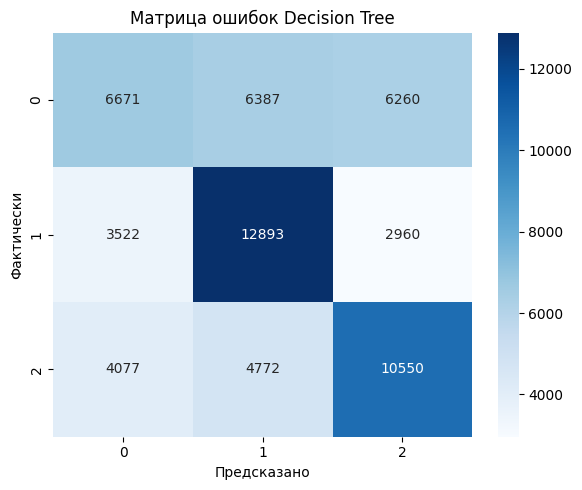

In [12]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказано')
plt.ylabel('Фактически')
plt.title('Матрица ошибок Decision Tree')
plt.tight_layout()
plt.show()

### Оценка точности:

In [13]:
error_rate = 1 - accuracy_score(y_test, y_pred_dt)
print("Ошибка:", error_rate)

Ошибка: 0.48161536872546995


## Задание 4. Обучите модель классификатора Random Forest Classifier для решения поставленной задачи

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

pipeline_rf = Pipeline([
    ('vect', TfidfVectorizer(max_features=2000, ngram_range=(1,1), sublinear_tf=True)),
    ('clf', RandomForestClassifier(
        n_estimators=100,          # количество деревьев
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

# обучение
pipeline_rf.fit(X_train, y_train)

# предсказание
y_pred_rf = pipeline_rf.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))



Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.47      0.48     19318
           1       0.63      0.70      0.66     19375
           2       0.62      0.60      0.61     19399

    accuracy                           0.59     58092
   macro avg       0.58      0.59      0.59     58092
weighted avg       0.58      0.59      0.59     58092



### Вывод матрицы ошибок:

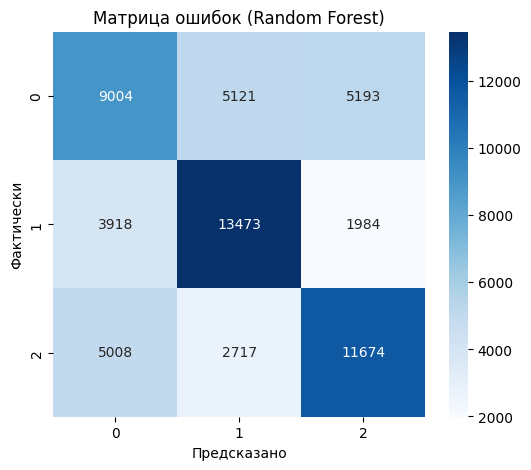

In [15]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок (Random Forest)')
plt.xlabel('Предсказано')
plt.ylabel('Фактически')
plt.show()

### Оценка точности:

In [16]:
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest accuracy: {acc_rf:.4f}")

Random Forest accuracy: 0.5879


## Подведите общие итоги и сделайте выводы

In [30]:
# Предсказание для SVM на тестовой выборке
y_pred_svm_test = best_svm.predict(X_test)

print(f"Naive Bayes: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"SVM: {accuracy_score(y_test, y_pred_svm_test):.4f}")
print(f"Decision Tree: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Random Forest: {accuracy_score(y_test, y_pred_rf):.4f}")

Naive Bayes: 0.7024
SVM: 0.3985
Decision Tree: 0.5184
Random Forest: 0.5879


Naive Bayes справился лучше всех, этот алгоритм создан для работы с текстом, поэтому он быстро учится и хорошо предсказывает
SVM показал почти такой же результат, тоже хорошо подходит для текстов, но работает чуть дольше.
Decision Tree: деревья плохо работают с текстовыми данными, потому что слов очень много, и модель путается.
Random Forest чуть улучшил результат дерева, но всё равно не догнал первые два метода.
